In [4]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
projects = pd.read_json("../src/data/projects.jsonl", lines=True)
projects["created_year"] = projects["created_at"].dt.year  # the year it was added to the site's database
projects.head()

,status,slug,name,company,company_slug,latitude,longitude,total_power_mw,city,county,state,description,full_address,gross_building_size,gross_colocation_space,total_space_sqft,created_at,listing_url,error,created_year
0,ok,amazon-aws-pdx4-boardman-or,"PDX4 Boardman, OR",Amazon AWS,amazon-aws,45.838493,-119.654163,NaN,boardman,Morrow County,oregon,<p>Experience the cutting-edge technology of A...,"79539 Rippee Road, Boardman, OR 97818, USA",NaN,NaN,NaN,2018-01-01 00:00:00+00:00,https://www.datacenters.com/amazon-aws-pdx4-bo...,NaN,2018.0
1,ok,oracle-us-east-us-ashburn-1,US East us-ashburn-1,Oracle,oracle,39.043719,-77.487490,NaN,ashburn,Loudoun County,virginia,<p>Each Oracle Cloud region supports our 100-p...,"Ashburn, VA, USA",NaN,NaN,NaN,2023-09-08 20:59:51+00:00,https://www.datacenters.com/oracle-us-east-us-...,NaN,2023.0
2,ok,microsoft-azure-north-central-us-illinois,North Central US-Illinois,Microsoft Azure,microsoft-azure,41.917253,-87.895619,NaN,northlake,Cook County,illinois,<p>As the Microsoft Cloud offers services and ...,"601 Northwest Avenue, Northlake, IL, USA",700000.0,NaN,700000.0,2018-01-01 00:00:00+00:00,https://www.datacenters.com/microsoft-azure-no...,NaN,2018.0
3,ok,amazon-aws-dublin-oh,Dublin OH,Amazon AWS,amazon-aws,40.090897,-83.200130,35.0,dublin-23,Madison County,ohio,<p>Secure by design: Our AWS data centers are ...,"5895 Houchard Road, Dublin, OH, USA",310000.0,NaN,310000.0,2018-01-01 00:00:00+00:00,https://www.datacenters.com/amazon-aws-dublin-oh,NaN,2018.0
4,ok,amazon-aws-2580-beech-rd,2580 Beech Rd,Amazon AWS,amazon-aws,40.093839,-82.754230,NaN,johnstown,Franklin County,ohio,None,"2580 Beech Rd NW, Johnstown, Ohio 43031, USA",NaN,NaN,NaN,2024-12-30 15:23:34+00:00,https://www.datacenters.com/amazon-aws-2580-be...,NaN,2024.0


In [17]:
data = projects[["total_power_mw", "total_space_sqft", "created_year"]].reset_index(drop=True)
data["log_power_mw"] = np.log(data["total_power_mw"])
data["log_space_sqft"] = np.log(data["total_space_sqft"])
model = ols("log_power_mw ~ log_space_sqft", data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           log_power_mw   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     217.9
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           5.08e-45
Time:                        21:03:06   Log-Likelihood:                -1850.7
No. Observations:                1070   AIC:                             3705.
Df Residuals:                    1068   BIC:                             3715.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4221      0.185     -2.

In [19]:
model = ols("total_power_mw ~ total_space_sqft", data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         total_power_mw   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     648.7
Date:                Sat, 11 Jul 2026   Prob (F-statistic):          3.39e-112
Time:                        21:04:12   Log-Likelihood:                -6064.4
No. Observations:                1070   AIC:                         1.213e+04
Df Residuals:                    1068   BIC:                         1.214e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.6418      2.395  

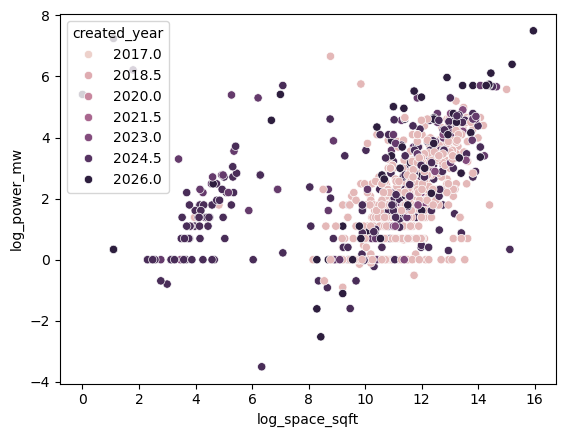

In [18]:
sns.scatterplot(data, x="log_space_sqft", y="log_power_mw", hue="created_year");